In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("cs1090a_hw1.ipynb")

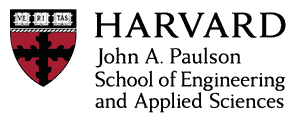

# CS1090A Introduction to Data Science
## Homework 1: A Reproducible Scraping & EDA Pipeline

**Harvard University**<br/>
**Fall 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, and Chris Gumb

<hr style="height:2.4pt">

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
import json
import time
import glob
import datetime
from concurrent.futures import ThreadPoolExecutor
from IPython import display

In [4]:
# For calculating total notebook runtime
notebook_start = time.time()

In [5]:
style = '''<style>
h2, h3, h4 {
    background-color: #7efcf5;
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    padding: 0em;
    color: #1F2937;
}
h3 {
    background-color: #7efcf5;
    border-top: 5px solid #7ec4fc;
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    padding: 0.5em;
}
div.md {
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    border-bottom: 5px solid #7ec4fc;
    padding: 0.5em;
}
div.prompt {
    background: #d1ffbd;
    border: thin solid black;
    border-radius: 2px;
    padding: 5px;
    margin: 0.5em 0;
    color: #1F2937;
}
/* A colour on the box does not reach <code> or <a> inside it. JupyterLab's dark
   theme gives inline code background-color: var(--jp-layout-color2) (#424242) and
   colours links #64b5f6, so setting only the box colour would put dark text on a
   dark code background. Code and links outside a box are left alone, where the
   theme's own pairing is already right. */
div.prompt code, div.alert code {
    background: rgba(0, 0, 0, 0.06);
    color: #1F2937;
}
div.prompt a, div.alert a {
    color: #1D4ED8;
}
</style>'''
display.display(display.HTML(style))

## Assignment Overview

You'll build a **reproducible data pipeline** around
[screenboston.com](https://screenboston.com), a site that aggregates movie
screenings from theaters around Boston. You will collect the data (live page +
historical snapshots), structure it with Pandas, enrich it from Wikipedia, use
EDA and visualization to understand it — and finish by making a **data-driven
recommendation** to the theaters themselves.

Think of the assignment is a structured mini-project. Each question tells
you the **goal**, the **required artifact** (file, variable, or figure), and any
**constraints** — how you get there is up to you. Sections 1–2 and the
supplemental notebooks (*MediaWiki API*, *Matplotlib & Seaborn reference*)
demonstrate every technique you'll need.

**The reproducibility theme.** A grader (or future you) should be able to re-run
your notebook and get the *same dataset and results*. Concretely, throughout
this assignment:

- **Guard every fetch** — code that touches the network must first check for a
  cached copy on disk and skip the request if it exists.
- **Derive results from pinned data** — that is, historical Wayback snapshots and cached
  files, not whatever the live web happens to say today.
- You will **submit your small data files** alongside the notebook (see
  Question 10), so your results are reproducible without the network.

**Structure** (10 questions + wrap-up; CS1090A graded out of 95, AC209A out of
100 — see the AC209A section):

1. Acquire the live page (4 pts)
2. Parse HTML into records (10 pts)
3. A reproducible dataset from Wayback snapshots (12 pts)
4. Build and clean a DataFrame (12 pts)
5. Exploratory data analysis (14 pts)
6. Resolve films to Wikipedia page IDs (8 pts)
7. Cache Wikipedia page content to disk (4 pts)
8. Enrich the data and ask a new question (10 pts)
9. **The decision: program Halloween weekend (14 pts)**
10. Reproducibility reflection & data submission (6 pts)
11. Wrap-up (1 pt)
12. **AC209A only:** SQL + concurrency (5 pts — required for AC209A; CS1090A
    students may skip this section entirely)

## Instructions

<div class="prompt" style="background: lightgreen; border: thin solid black; border-radius: 2px; padding: 5px; color: #1F2937;">

**General**
- To submit your notebook and data files, follow the instructions on the Canvas assignment page.
- **CS1090A is graded out of 95; AC209A is graded out of 100.** Three subquestions are marked *AC209A only*: 6a and 7a (concurrency evidence, 1 point each) and 8a (SQL, 3 points). CS1090A students skip those three and lose nothing by doing so — they are required work for AC209A, not extra credit for anyone.
- Plots must be legible and interpretable *without reading the code that generated them*: axis labels, a descriptive title, and a legend where appropriate.
- When asked to interpret a result, explain what it *means* — not what the plot looks like.
- The automated tests are **smoke tests only**: they check that required artifacts exist and have the right shape. Passing them is necessary, not sufficient — most credit is assigned by rubric to your approach, analysis, and writing.
- Your code must be **re-runnable — including offline**: "Restart Kernel and Run All Cells" must complete without error, and given your submitted data files it must complete *without any network access* (this is how it will be graded). 
- Only make network requests when the corresponding cache is empty. Gratuitous re-fetching (of pages you already saved) will lose credit.
- Feel free to add code or markdown cells. Include a written response wherever a question asks for one.
- **Before submitting: Restart Kernel and Run All Cells**, confirm no errors and that all output is visible.

**Use of AI tools**

AI tools — coding agents especially — are part of the modern data science workflow. One principle governs everything: **you are accountable for whatever you submit.** You must understand it, be able to communicate it, and be able to justify it.

- Written interpretations, the Question 9 memo, and the Question 10 reflection must be **your own reasoning in your own words**.
- In Question 10 you will briefly **disclose** how you used AI on this assignment and what you did to verify its output.
- Remember, any understanding you skip here will be paid for later in quizzes & midterms.
</div>

## Question 1: Acquire the live page

<p>Get the current HTML of <a href="https://screenboston.com">screenboston.com</a> and cache it to disk.</p>

<p><b>Why HTML at all?</b> Before scraping any site, look for structured data first — an official API, or the JSON many modern sites load their pages from. screenboston has one: <code>screenboston.com/__data.json</code> serves the current schedule as JSON, and parsing it would be easier than parsing HTML. We parse HTML anyway for one decisive reason: this assignment's dataset is <i>historical</i>, and the past only exists in the Wayback Machine's snapshots of the <i>rendered page</i>.</p>

<div class=prompt>

**Artifact:** the file <code>data/html/screenboston.html</code>.

**Constraints:**
- The fetch must be <b>guarded</b>: make an HTTP request only if the file does not already exist.
- <b>Identify yourself</b>: send a descriptive <code>User-Agent</code> naming the course. Some sites block anonymous default clients.
</div>

<p><b>Note what you just built:</b> this file is the one piece of your dataset that is <i>not</i> reproducible — it captures whatever the site showed on the day you ran this cell. (We'll fix that in Question 3)</p>

In [9]:
# your code here
os.makedirs('data/html', exist_ok=True)
live_path = 'data/html/screenboston.html'

# Identify myself
headers = {'User-Agent': 'CS1090A-HW1'}

# Only touch the network if the cached file does not exist
if not os.path.exists(live_path):
    resp = requests.get('https://screenboston.com', headers=headers, timeout=30)
    resp.raise_for_status()    # raise on 4xx/5xx so an error page is never cached
    with open(live_path, 'wb') as f:  # write raw bytes -> no re-encoding surprises
        f.write(resp.content)
    print(f'Fetched live page (HTTP {resp.status_code}) and saved to {live_path}')
else:
    print(f'Cache hit: {live_path} exists, no request made')

print(f'{live_path}: {os.path.getsize(live_path):,} bytes')

Cache hit: data/html/screenboston.html exists, no request made
data/html/screenboston.html: 281,924 bytes


In [10]:
grader.check("q1")

q1 results: All test cases passed!

## Question 2: Parse the HTML into records

<p>Turn the page into structured data: one record per screening (a film, at a theater, on a date).</p>

<div class=prompt>

**Artifact:** a list of dictionaries named <code>movies</code>, one per screening, each with <i>exactly</i> these keys:

```python
{'title': 'Monty Python and the Holy Grail',
 'directors': 'Terry Jones, Terry Gilliam',   # plural key, even for one director
 'year': 1975,                                 # int
 'genre': 'Adventure',
 'runtime': '1h 31m',
 'theater': 'Coolidge Corner Theatre',
 'screen_date': '2026-07-11',
 'screen_times': '11:59 PM'}
```

**Constraints:**
- Write your parsing as <b>reusable function(s)</b> that take an HTML string — Question 3 will run them on ~20 more pages.
- Report how many records you extracted and display one example.
- Some listings are missing fields; a record with a <code>None</code> value is fine, but don't let one malformed listing crash the whole parse.
- <b>Never fail silently.</b> Your parser must also report how many listings it <i>failed</i> to parse. A page whose structure has drifted enough to break the parser should announce itself ("parsed 0 of 66 listings") — silent errors cause issues downstream and are a nightmare to debug.
</div>

**Hints:** your browser's *inspect* tool is how you learn the page's structure. Screening dates are not inside each listing — look at what *contains* the listings.

In [12]:
# your code here

def looks_like_runtime(s):
    """True for strings such as '1h 31m', '3h' or '30m'."""
    s = s.lower()
    return any(ch.isdigit() for ch in s) and ("h" in s or "m" in s)


def get_date(listing):
    """The date sits on an *ancestor* <div id="YYYY-MM-DD">, walk up until an id looks like a date."""
    node = listing.find_parent(id=True)
    while node and not re.match(r"^\d{4}-\d{2}-\d{2}$", node.get("id", "")):
        node = node.find_parent(id=True)
    return node["id"] if node else None          # None if we ran out of ancestors


def get_info(raw):
    """'1975, Adventure, 1h 31m' -> (1975, 'Adventure', '1h 31m')"""
    parts = [x.strip() for x in (raw or "").split(",") if x.strip()]
    year, genre, runtime = None, None, None
    if parts and parts[0].isdigit():             # the year comes first when it is present
        year = int(parts.pop(0))
    for p in parts:                        
        if looks_like_runtime(p):
            runtime = p
        else:
            genre = p
    return year, genre, runtime


def get_record(listing):
    """One listing -> one dict with the 8 required keys. Raises if the film can't even be identified."""
    title = listing.select_one("p.big").get_text(strip=True)        
    # AttributeError if there is no title right after the title's block sits a row with two columns:
    # left  = [directors (optional), "year, genre, runtime"]     
    # right = [theater, showtime, showtime, ...]
    row = listing.select_one("p.big").find_parent("div").find_next_sibling("div")
    left, right = row.find_all("div", recursive=False)[:2]
    left_ps = [p.get_text(strip=True) for p in left.select("p")]
    right_ps = [p.get_text(strip=True) for p in right.select("p")]

    year, genre, runtime = get_info(left_ps[-1] if left_ps else None)
    return {
        "title": title,
        "directors": left_ps[0] if len(left_ps) > 1 else None,
        "year": year,
        "genre": genre,
        "runtime": runtime,
        "theater": right_ps[0] if right_ps else None,
        "screen_date": get_date(listing),
        "screen_times": ", ".join(right_ps[1:]) or None,
    }


def parse_page(html, label="page"):
    """HTML string -> list of screening records. Prints how many listings failed.

    Returns records only, so `all_records.extend(parse_page(html))` works in Q3.
    """
    listings = BeautifulSoup(html, "html.parser").select("button .flex-col")
    if not listings:
        raise ValueError("no 'button .flex-col' listings -- has the page structure changed?")
    records, failed = [], 0
    for li in listings:
        try:
            records.append(get_record(li))
        except Exception:
            failed += 1
    print(f"{label}: parsed {len(records)} of {len(listings)} listings, {failed} failed")
    return records


# Run it on the live page in Q1
with open("data/html/screenboston.html", encoding="utf-8") as f:
    movies = parse_page(f.read(), label="live page")

print(f"{len(movies)} records extracted. One example:")
movies[0]

live page: parsed 115 of 115 listings, 0 failed
115 records extracted. One example:


{'title': 'Hunt for the Wilderpeople',
 'directors': 'Taika Waititi',
 'year': 2016,
 'genre': 'Adventure',
 'runtime': '1h 41m',
 'theater': 'The Brattle',
 'screen_date': '2026-09-20',
 'screen_times': '12:00 PM, 9:00 PM'}

In [13]:
grader.check("q2")

q2 results: All test cases passed!

## Question 3: A reproducible dataset from Wayback snapshots

<p>The live page only shows the next couple of weeks. The Internet Archive's
<a href="https://archive.org/help/wayback_api.php">Wayback Machine availability API</a> lets you retrieve historical snapshots of the page — and because snapshots are <b>pinned</b>, a dataset built from them is reproducible.</p>

<div class=prompt>

**Artifacts:**
1. Snapshot HTML files saved as <code>data/html/snapshot_YYYYMMDD.html</code> — covering <b>all available snapshots</b> of screenboston.com <b>through September 8, 2026</b>.
2. <code>data/movies.json</code> — the combined list of screening records parsed from <i>every</i> HTML file in <code>data/html/</code> (snapshots + live page), written with the <code>json</code> module.

**Constraints:**
- Both steps must be <b>guarded</b> (i.e., check for existing cache before running) — and guard <b>per file</b>, so an interrupted run resumes instead of restarting (or worse, permanently locking in a partial download).
- <b>The archive spans a site redesign.</b> These snapshots run over two years, and
screenboston.com did not look the same throughout. At least one early snapshot will not
parse with selectors written for today's page. Your parser must <b>say so</b> rather than
quietly return an empty list — that is what "never fail silently" in Q2 was for.
<i>Extracting that page's listings anyway is optional and worth a bonus point</i>; be
warned that the older layout carries no release year at all, so <code>year</code> would
have to be <code>None</code> for those records.
- <b>Expect throttling and handle it.</b> The whole class hits archive.org the same week; you *will* see slow responses or HTTP 429. Check status codes before parsing or saving anything — a cached error page is worse than no cache (since a simple guard can't tell them apart). Sanity-check each saved snapshot (does it parse to a plausible number of listings?).
- Assume any well-formed page covers at least through the end of its snapshot month, and that a day's schedule doesn't change once displayed.
- Don't worry about duplicate screenings across overlapping snapshots — Question 4 deals with them.
- Report which snapshots you found and the total number of records.
</div>

**Hint:** the availability API returns the snapshot *closest* to a timestamp — probing one timestamp per month is a reasonable way to sweep the archive's history. Store your list in `movies` (it should now include records from all pages).

In [15]:
# your code here
#Step 1: Download every Wayback snapshot of screenboston.com taken up to Sept 8, 2026.
HEADERS = headers                  
CUTOFF = "20260908"              
WB_API = "https://archive.org/wayback/available"


def get_checked(url, tries=4, **kwargs):
    """Download `url`, waiting and retrying if we are throttled. Returns the response, or None if it never worked."""
    for attempt in range(tries):
        try:
            r = requests.get(url, headers=HEADERS, timeout=60, **kwargs)
        except requests.RequestException as e:               # e.g. a timeout or a dropped connection
            print(f"  {type(e).__name__} -- waiting, then retrying")
            time.sleep(2 ** attempt)
            continue

        if r.status_code in (429, 503):                      
            wait = 2 ** attempt                              # wait 1, 2, 4, 8 seconds
            if r.headers.get("Retry-After", "").isdigit():   # unless the server tells us how long
                wait = min(int(r.headers["Retry-After"]), 60)   # but never wait more than 60 seconds
            print(f"  throttled (HTTP {r.status_code}); waiting {wait}s")
            time.sleep(wait)
            continue

        if r.ok:   # status 200-299 means success
            return r
        print(f"  HTTP {r.status_code} -- giving up on {url[:60]}")
        return None    # any other error (404, 500, ...): do not retry

    print(f"  still failing after {tries} tries -- skipping {url[:60]}")
    return None


def looks_real_snapshot(response, min_chars=5_000, marker=r"screen\W?boston"):
    """Raise an error if `response` is an error or throttle page instead of a real copy of the site."""
    response.raise_for_status()                              # check 1: the HTTP status must be OK
    if len(response.text) < min_chars:                       # check 2: error pages are tiny, real pages are large
        raise ValueError(f"only {len(response.text):,} characters")
    if not re.search(marker, response.text, re.IGNORECASE):  # check 3: the page must show the site name
        raise ValueError("the site name is not in the body")  # (matches Screen Boston / Screen.Boston / ScreenBoston)
    # We deliberately do NOT check whether our parser can read the page. Old snapshots use a
    # different layout that the parser can't handle, but they are still real copies: we save
    # them here and report the parse failure later, in step 2.


def find_snapshots(page_url, manifest_file, cutoff, years):
    """Ask the Wayback API for the snapshot closest to the 1st of every month. Returns {YYYYMMDD: snapshot url}."""
    # If we already did this once, read the saved answer instead of asking archive.org again
    if os.path.isfile(manifest_file):
        with open(manifest_file, encoding="utf-8") as f:
            return json.load(f)

    found = {}                                           
    n_failed = 0
    for year in years:
        for month in range(1, 13):
            stamp = f"{year}{month:02d}01"                   
            if stamp > cutoff:       # do not ask about dates after the cutoff
                continue
            r = get_checked(WB_API, params={"url": page_url, "timestamp": stamp})
            time.sleep(1)            # short pause
            if r is None:           
                n_failed += 1
                continue
            closest = r.json().get("archived_snapshots", {}).get("closest")   # missing if nothing is archived
            if closest and closest["timestamp"][:8] <= cutoff:   # the closest one can lie after the cutoff
                date = closest["timestamp"][:8]                  # the first 8 digits are YYYYMMDD
                found[date] = closest["url"].replace("http://", "https://", 1)

    # Save the list only if every question was answered, otherwise a re-run would reuse an incomplete list
    if n_failed == 0:
        with open(manifest_file, "w", encoding="utf-8") as f:
            json.dump(found, f, indent=1)
    else:
        print(f"WARNING: {n_failed} lookups failed, so the list was NOT saved. Re-run this cell.")
    return found


def download_snapshots(found, out_dir):
    """Save each snapshot as out_dir/snapshot_YYYYMMDD.html, one file at a time."""
    os.makedirs(out_dir, exist_ok=True)
    saved, skipped = 0, 0
    for date, url in sorted(found.items()):
        path = f"{out_dir}/snapshot_{date}.html"
        if os.path.isfile(path):  # guard for THIS file: already downloaded, skip it
            skipped += 1
            continue
        r = get_checked(url)
        time.sleep(1)
        if r is None:     # never worked: save nothing, the next run retries it
            continue
        r.encoding = "UTF-8"    # set this BEFORE reading r.text (avoids garbled text)
        try:
            looks_real_snapshot(r)  # check the response BEFORE saving it
        except Exception as e:
            print(f"  snapshot_{date}: rejected ({e}) -- not saved")
            continue
        with open(path, "w", encoding="utf-8") as f:
            f.write(r.text)
        saved += 1
        print(f"  saved snapshot_{date}.html")
    print(f"{len(found)} snapshots found: {saved} saved now, {skipped} already on disk")


found = find_snapshots("screenboston.com", "data/wayback_manifest.json", CUTOFF, years=(2023, 2024, 2025, 2026))
download_snapshots(found, "data/html")
print("Snapshots found:", sorted(found))

21 snapshots found: 0 saved now, 21 already on disk
Snapshots found: ['20240328', '20240524', '20241006', '20241101', '20241206', '20250326', '20250428', '20250616', '20250622', '20250903', '20251021', '20251127', '20251215', '20260123', '20260312', '20260413', '20260513', '20260616', '20260708', '20260721', '20260827']


In [16]:
# your code here
# Step2: Parse every html file in data/html (snapshots + live page) into one combined data/movies.json.

# The pre-redesign layout, early 2024. Its listings are inside <a> tags, dates have no year,
# and the info line is "format, genre, runtime", so `year` is None for these records.
def get_record_old(block, listing, taken):
    """One old-layout listing -> record dict. `block` holds the date, `taken` is the day the snapshot was taken."""
    title = listing.select_one("p.big")
    row = title.find_next_sibling("div")  # here the row sits right after the title itself
    left, right = row.find_all("div", recursive=False)[:2]   # [directors, info line] and [theater, showtimes]
    left_ps = [p.get_text(strip=True) for p in left.select("p")]
    right_ps = [p.get_text(strip=True) for p in right.select("p")]

    info = [x.strip() for x in left_ps[-1].split(",")]       # e.g. ["DCP", "Thriller", "2h 3m"]
    _, genre, runtime = get_info(", ".join(info[1:]))        # drop the leading format (DCP / 35mm)

    date_text = block.select_one("p.col-span-1").get_text(strip=True)          # e.g. "Sat Mar 30" (no year)
    date = pd.to_datetime(f"{date_text.split(maxsplit=1)[1]} {taken.year}", format="%b %d %Y")
    if date < taken - pd.Timedelta(days=30): # a December snapshot listing January dates
        date = date.replace(year=date.year + 1)
    return {
        "title": title.get_text(strip=True),
        "directors": left_ps[0] if len(left_ps) > 1 else None,
        "year": None,  # the old layout has no release year
        "genre": genre,
        "runtime": runtime,
        "theater": right_ps[0] if right_ps else None,
        "screen_date": date.strftime("%Y-%m-%d"),
        "screen_times": ", ".join(right_ps[1:]) or None,
    }


def parse_old_page(html, label="page"):
    """HTML string (old layout) -> list of records. Raises ValueError if the page has no old-layout listings."""
    soup = BeautifulSoup(html, "html.parser")
    header = soup.select_one("button.big")                   # e.g. "Thu Mar 28 2024": the day the snapshot was taken
    pairs = [(block, a) for block in soup.select("div.grid.gap-2 > div") for a in block.select("a")]
    if header is None or not pairs:
        raise ValueError("no old-layout listings either")
    taken = pd.to_datetime(header.get_text(strip=True), format="%a %b %d %Y")
    records, failed = [], 0
    for block, a in pairs:
        try:
            records.append(get_record_old(block, a, taken))
        except Exception:
            failed += 1
    print(f"{label} (old layout): parsed {len(records)} of {len(pairs)} listings, {failed} failed")
    return records


def parse_any(html, label="page"):
    """Try today's layout first; if that finds no listings, fall back to the pre-redesign layout."""
    try:
        return parse_page(html, label=label)
    except ValueError:
        return parse_old_page(html, label=label)


def check_page(label, records):
    """Print a warning if a snapshot's dates stop before the end of its own month (page may be incomplete)."""
    match = re.match(r"snapshot_(\d{8})", label)             # the live page has no date in its file name
    dates = sorted(r["screen_date"] for r in records if r["screen_date"])
    if match and dates:
        month_end = (pd.Timestamp(match[1]) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")
        if dates[-1] < month_end:
            print(f"  WARNING {label}: dates only reach {dates[-1]}, before the month end {month_end}")


def build_dataset(html_glob, out_json, parse):
    """Parse every saved page into one list of records and write it to `out_json`."""
    paths = sorted(glob.glob(html_glob))
    assert paths, f"no files match {html_glob}"

    # If movies.json was written AFTER the newest html file was saved, there is nothing new to parse.
    # If a snapshot arrives later, the html file is newer than movies.json, so we rebuild it.
    newest_html = max(os.path.getmtime(p) for p in paths)
    if os.path.isfile(out_json) and os.path.getmtime(out_json) >= newest_html:
        with open(out_json, encoding="utf-8") as f:
            records = json.load(f)
        print(f"{out_json} is up to date -- loaded {len(records)} records")
        return records

    all_records = []
    counts = {}  # file name, number of records parsed from it
    unparseable = []  # files our parser could not read
    for path in paths:
        label = os.path.basename(path)
        with open(path, encoding="utf-8") as f:
            try:
                records = parse(f.read(), label=label)
            except ValueError as e:  # raised when the page has no listings at all
                print(f"{label}: NOT PARSED -- {e}")
                records = []
        if len(records) == 0:  # raised an error or found nothing, report it either way
            unparseable.append(label)
            continue
        all_records.extend(records)
        counts[label] = len(records)
        check_page(label, records)

    # A file with far fewer records than the typical file is suspicious
    typical = pd.Series(counts).median()
    for label, n in counts.items():
        if n < 0.5 * typical:
            print(f"  WARNING {label}: only {n} records (typical file: {typical:.0f}) -- incomplete page?")

    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(all_records, f, indent=1)
    print(f"{len(all_records)} records from {len(counts)} of {len(paths)} files -> {out_json}")
    if unparseable:
        print("Could not parse (layout differs from today's page):", unparseable)
    return all_records


movies = build_dataset("data/html/*.html", "data/movies.json", parse_any)

data/movies.json is up to date -- loaded 1834 records


In [17]:
# Display info about snapshots and parse results
print("Snapshots on disk:")
print(sorted(os.path.basename(f) for f in glob.glob('data/html/snapshot_*')))
print(f"{len(movies)} total screening records across all HTML files.")

Snapshots on disk:
['snapshot_20240328.html', 'snapshot_20240524.html', 'snapshot_20241006.html', 'snapshot_20241101.html', 'snapshot_20241206.html', 'snapshot_20250326.html', 'snapshot_20250428.html', 'snapshot_20250616.html', 'snapshot_20250622.html', 'snapshot_20250903.html', 'snapshot_20251021.html', 'snapshot_20251127.html', 'snapshot_20251215.html', 'snapshot_20260123.html', 'snapshot_20260312.html', 'snapshot_20260413.html', 'snapshot_20260513.html', 'snapshot_20260616.html', 'snapshot_20260708.html', 'snapshot_20260721.html', 'snapshot_20260827.html']
1834 total screening records across all HTML files.


In [18]:
grader.check("q3")

q3 results: All test cases passed!

## Question 4: Build and clean a DataFrame

<div class=prompt>

**Artifact:** a DataFrame <code>df</code> built from <code>data/movies.json</code>, satisfying:

1. **No duplicate rows** (rows where *all* values match — overlapping snapshots create many). Report how many rows you dropped and how many remain.
2. A **missingness audit**: NaN counts per column, and a display of the rows containing at least one NaN (or confirmation there are none).
3. **A dtype on each column that matches what the column holds**: <code>screen_date</code> as a datetime type, <code>runtime</code> as a timedelta type.
4. Sorted by ascending <code>screen_date</code>.

<b>Verify as you go</b> — after each transform, check what you actually produced (<code>.shape</code>, <code>.dtypes</code>, a spot-check of rows). Whether you or an 'assistant' wrote the code, the sign-off on the result is your responsibility.

Then use the clean frame to create:

5. A table of **screenings per theater per calendar month** (rows = month, columns = theater; restrict columns to the 6 busiest theaters). Then, in one or two sentences: what do you notice?
</div>

In [20]:
# your code here
with open("data/movies.json", encoding="utf-8") as f:
    df = pd.DataFrame(json.load(f))  # a list of dicts, one row per screening
print("raw data:", df.shape)

# 1. Duplicates: overlapping snapshots repeat the same screenings. Drop rows where ALL values match.
n_before = len(df)
df = df.drop_duplicates()
print(f"dropped {n_before - len(df)} duplicate rows; {len(df)} rows remain")

# 2. Missingness audit: how many NaN values in each column, and in which rows
print("\nNaN count per column:")
print(df.isna().sum())
rows_with_nan = df[df.isna().any(axis=1)] # rows with at least one NaN
print(f"\n{len(rows_with_nan)} rows contain at least one NaN:")
display.display(rows_with_nan)

# 3. Give every column a dtype that matches what it holds.
def to_timedelta(text):
    """'1h 41m' -> 1 hour 41 minutes; '4h' -> 4 hours; '45m' -> 45 minutes; anything else -> NaT (missing)."""
    if pd.isna(text):
        return pd.NaT
    match = re.fullmatch(r"(?:(\d+)h)?\s*(?:(\d+)m)?", text.strip())   # hours and minutes are both optional
    if match is None or not any(match.groups()): # empty or unexpected text
        return pd.NaT
    hours, minutes = match.groups()
    return pd.Timedelta(hours=int(hours or 0), minutes=int(minutes or 0))

n_runtime_missing = df["runtime"].isna().sum() # remember, so we can check nothing new goes missing

df["screen_date"] = pd.to_datetime(df["screen_date"]) # text 'YYYY-MM-DD', datetime
df["runtime"] = df["runtime"].map(to_timedelta) # text '1h 41m', timedelta
df["year"] = df["year"].astype("Int64") # whole numbers that may be missing (a float column would show 1975.0)

# The site uses 6666 as a placeholder year for "mystery" screenings. A year outside 1890-2027 can't be real, so treat it as missing.
bad_year = (df["year"] < 1890) | (df["year"] > 2027)
print("placeholder/impossible years set to missing:", bad_year.sum())
df.loc[bad_year.fillna(False), "year"] = pd.NA  # fillna(False): rows whose year is already missing are left alone

df["genre"] = df["genre"].astype("category") # only a few distinct values, category
df["theater"] = df["theater"].astype(str)

# Verify the conversions: no runtime text may have failed to convert
assert df["runtime"].isna().sum() == n_runtime_missing, "some runtime strings could not be converted!"

# 4. Sort by screen_date
df = df.sort_values(["screen_date", "theater", "title"]).reset_index(drop=True)
assert df["screen_date"].is_monotonic_increasing

# Verify: shape, dtypes, and a spot check of the rows
print("\nfinal shape:", df.shape)
print(df.dtypes)
display.display(df.head(3))
print("longest runtime:", df["runtime"].max(), "| shortest:", df["runtime"].min())

raw data: (1834, 8)
dropped 132 duplicate rows; 1702 rows remain

NaN count per column:
title           0
directors       0
year            2
genre           5
runtime         0
theater         0
screen_date     0
screen_times    0
dtype: int64

7 rows contain at least one NaN:


,title,directors,year,genre,runtime,theater,screen_date,screen_times
115,Blue Giant,Yuzuru Tachikawa,NaN,Thriller,2h,Museum of Fine Arts,2024-03-30,7:00 PM
116,Perfect Days,Wim Wenders,NaN,Thriller,2h 3m,Museum of Fine Arts,2024-04-05,7:00 PM
594,Alpe-Adria Underground!,"Matevž Jerman, Jurij Meden",2024.0,None,1h 38m,Harvard Film Archive,2025-04-13,7:00 PM
865,I like America and America likes Me,Helmut Wietz,1974.0,None,0h 40m,Goethe-Institut,2025-09-12,6:00 PM
902,Hello Beautiful,Ziad H. Hamzeh,2025.0,None,1h 40m,West Newton Cinema,2025-09-18,7:00 PM
908,Hello Beautiful,Ziad H. Hamzeh,2025.0,None,1h 40m,West Newton Cinema,2025-09-19,7:00 PM
1036,No! YOU'RE WRONG. or: Spooky Action at a Distance,Crispin Glover,2025.0,None,1h 25m,Coolidge Corner Theatre,2025-11-03,7:00 PM


placeholder/impossible years set to missing: 3

final shape: (1702, 8)
title                    object
directors                object
year                      Int64
genre                  category
runtime         timedelta64[ns]
theater                  object
screen_date      datetime64[ns]
screen_times             object
dtype: object


,title,directors,year,genre,runtime,theater,screen_date,screen_times
0,Blue Giant,Yuzuru Tachikawa,<NA>,Thriller,0 days 02:00:00,Museum of Fine Arts,2024-03-30,7:00 PM
1,Perfect Days,Wim Wenders,<NA>,Thriller,0 days 02:03:00,Museum of Fine Arts,2024-04-05,7:00 PM
2,Big Trouble in Little China,John Carpenter,1986,Comedy,0 days 01:40:00,Coolidge Corner Theatre,2024-05-24,11:59 PM


longest runtime: 1 days 00:00:00 | shortest: 0 days 00:00:00


In [21]:
# your code here
# Screenings per theater per calendar month, for the 6 busiest theaters.
top6 = df["theater"].value_counts().head(6).index   # the 6 theaters with the most screenings
month = df["screen_date"].dt.to_period("M")    # calendar month of each screening, e.g. 2025-03

screenings = pd.crosstab(month, df["theater"])[top6]         # rows = month, columns = theater
all_months = pd.period_range(month.min(), month.max(), freq="M")
screenings = screenings.reindex(all_months, fill_value=0)    # months with no data at all show up as rows of 0
screenings.index.name = "month"
screenings

theater,The Brattle,Coolidge Corner Theatre,Harvard Film Archive,Somerville Theatre,West Newton Cinema,Museum of Fine Arts
month,,,,,,
2024-03,0,0,0,0,0,1
2024-04,0,0,0,0,0,1
2024-05,18,8,0,3,0,3
2024-06,48,24,0,1,1,9
2024-07,0,1,0,0,0,0
2024-08,0,0,0,0,0,0
2024-09,0,0,0,0,0,0
2024-10,47,31,23,28,0,2
2024-11,36,28,22,4,1,2


*The Brattle and Coolidge Corner Theatre are generally the busiest venues, though not every month. Activity varies substantially by month, and there are simultaneous zeros across all theaters, especially August–September 2024 and January–February 2025, which might reflect months that no snapshot covered rather than actual theater closures.*

In [23]:
grader.check("q4")

q4 results: All test cases passed!

## Question 5: Exploratory data analysis

Every visualization needs: labeled axes, descriptive title, and a written interpretation of what it *means*.
These are relatively simple visualizations. You should really try writing them yourself.

(Note: "Screening" refers to one row of the `df`.)

### 5.1 Longest films

Display the 10 longest reported runtimes (rows, descending).

Then, in one or two sentences: what are these longest entries, and what does that tell you about what the `runtime` column is measuring?

In [26]:
# your code here
longest = df.sort_values("runtime", ascending=False).head(10)
longest[["title", "directors", "year", "genre", "runtime", "theater", "screen_date"]]

,title,directors,year,genre,runtime,theater,screen_date
1097,51st Annual Boston Science Fiction Film Marathon,Various,2026,SciFi,1 days 00:00:00,Somerville Theatre,2026-02-15
1570,Marathon '77,Various,1977,Drama,0 days 13:00:00,Harvard Film Archive,2026-09-12
1143,The Lord of the Rings Trilogy,Peter Jackson,2001,Family,0 days 12:45:00,Coolidge Corner Theatre,2026-03-22
500,The Lord of the Rings Trilogy,Peter Jackson,2001,Fantasy,0 days 12:45:00,Coolidge Corner Theatre,2025-05-04
1164,The Lord of the Rings Trilogy,Peter Jackson,2001,Fantasy,0 days 12:45:00,Coolidge Corner Theatre,2026-03-29
229,23rd Halloween Horror Marathon,Coolidge Corner After Midnite,2024,Horror,0 days 12:00:00,Coolidge Corner Theatre,2024-10-26
810,24th Halloween Horror Marathon,Various,2025,Horror,0 days 12:00:00,Coolidge Corner Theatre,2025-10-25
876,GODZILLATHON,Various,1954,Horror,0 days 11:40:00,Somerville Theatre,2025-11-08
1219,Satantango,Béla Tarr,1994,Drama,0 days 07:12:00,Harvard Film Archive,2026-04-25
1520,"Triple Feature: Malkovich, Malkovich, Malkovich!","Clint Eastwood, Stephen Frears, Spike Jonze",1988,Drama,0 days 05:59:00,Coolidge Corner Theatre,2026-08-30


*Most of the longest entries are marathons or trilogies rather than individual films. So runtime measures the length of the whole screening event rather than strictly the length of one film.*

### 5.2 Screening counts

Side-by-side subplots with a shared y-axis: screenings by theater, and screenings by genre.

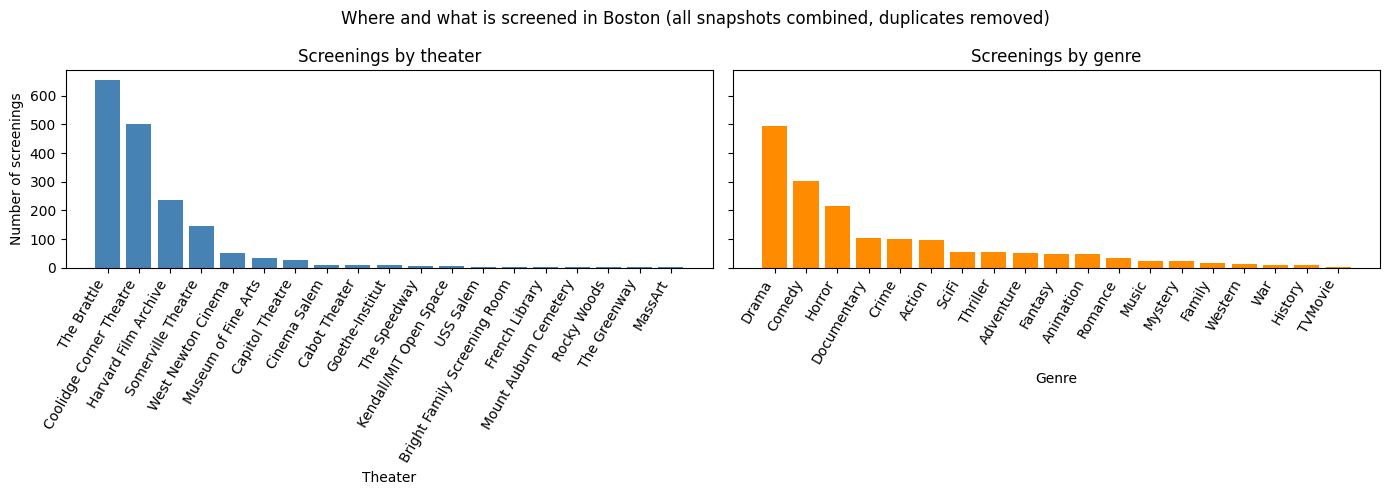

In [29]:
# your code here
# Screenings by theater and by genre
theater_counts = df["theater"].value_counts()
genre_counts = df["genre"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(14, 5))

ax1.bar(theater_counts.index, theater_counts.values, color="steelblue")
ax1.set_title("Screenings by theater")
ax1.set_xlabel("Theater")
ax1.set_ylabel("Number of screenings")

ax2.bar(genre_counts.index, genre_counts.values, color="darkorange")
ax2.set_title("Screenings by genre")
ax2.set_xlabel("Genre")

for ax in (ax1, ax2):
    plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
fig.suptitle("Where and what is screened in Boston (all snapshots combined, duplicates removed)")
plt.tight_layout()
plt.show()

*The screenings are very concentrated. The Brattle and Coolidge Corner Theatre account for most screenings. Drama is the most frequently screened genre, followed by comedy and horror. Boston’s repertory film programming is centered on a small number of major theaters and a few broadly popular genres.*

### 5.3 Film vintage

A pair of plots showing the distribution of release `year`, overall and broken out by theater (your choice of plot types, but justify the choice).

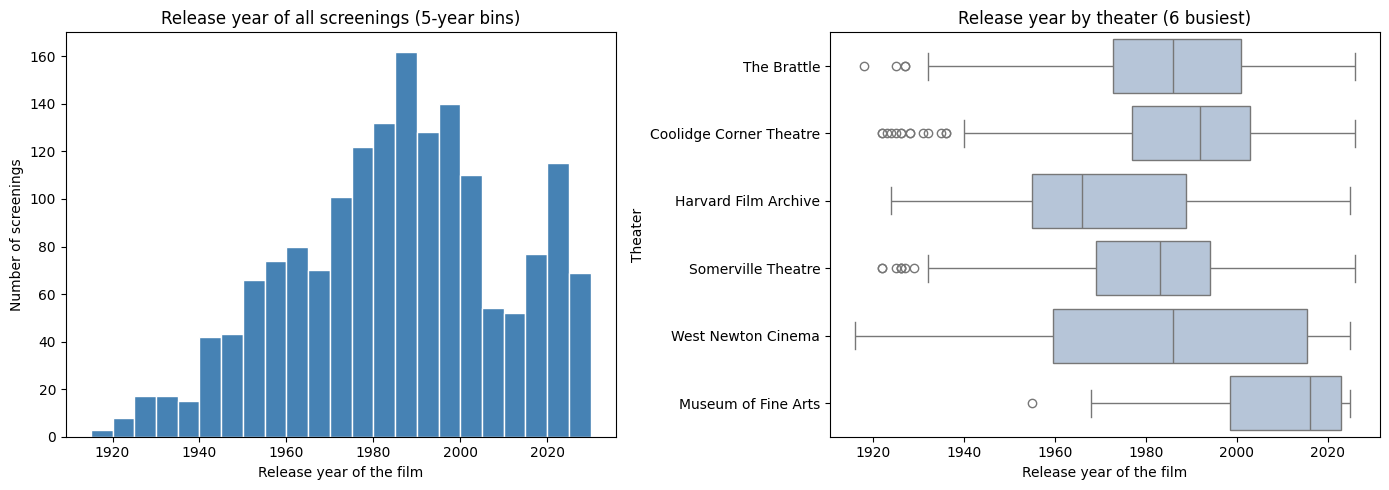

In [32]:
# your code here
# Distribution of release year, overall and by theater
films = df.dropna(subset=["year"]).copy()                    # no release year
films["year"] = films["year"].astype(int)                    # nullable Int64

top6 = df["theater"].value_counts().head(6).index            # 6 busiest theaters
films_top6 = films[films["theater"].isin(top6)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of every screening's release year, 5-year bins
start = films["year"].min() // 5 * 5
ax1.hist(films["year"], bins=range(start, films["year"].max() + 6, 5), color="steelblue", edgecolor="white")
ax1.set_title("Release year of all screenings (5-year bins)")
ax1.set_xlabel("Release year of the film")
ax1.set_ylabel("Number of screenings")

# Right: one box per theater
sns.boxplot(data=films_top6, x="year", y="theater", order=top6, color="lightsteelblue", ax=ax2)
ax2.set_title("Release year by theater (6 busiest)")
ax2.set_xlabel("Release year of the film")
ax2.set_ylabel("Theater")

plt.tight_layout()
plt.show()

*I used a histogram for the overall distribution because it shows how screening counts vary across release periods. I used box plots by theater because they allow comparisons of each theater’s median release year, spread, and unusually old films. The Museum of Fine Arts tends to screen newer films, while the Harvard Film Archive has the earliest median release year.*

### 5.4 One custom question

Pose a question of your own about the screening data and answer it with an appropriate plot whose *type differs* from those you used above. State the question, your approach, the plot, and your interpretation.

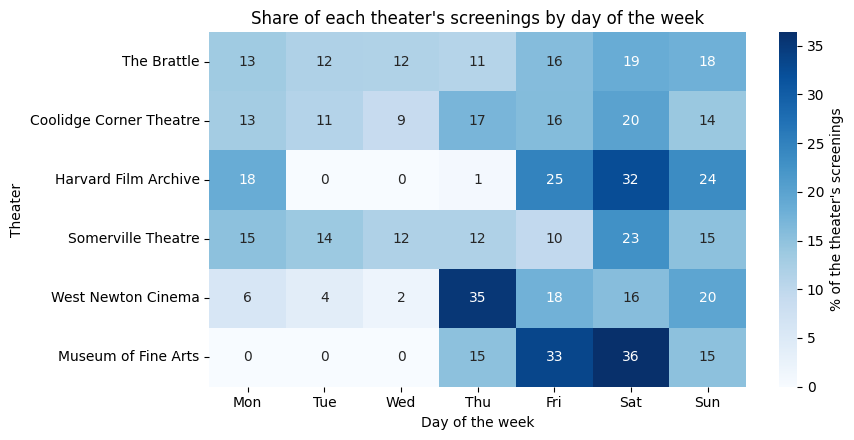

A theater with no weekday preference would show about 14 % in every cell.


In [35]:
# your code here
# Question: do theaters hold their screenings on particular days of the week?
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
top6 = df["theater"].value_counts().head(6).index
busy = df[df["theater"].isin(top6)]

weekday = busy["screen_date"].dt.day_name().str[:3]
share = pd.crosstab(busy["theater"], weekday, normalize="index") * 100   # each row adds up to 100%
share = share.loc[top6, days]   # busiest theater first, weekdays in calendar order

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(share, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% of the theater's screenings"}, ax=ax)
ax.set_title("Share of each theater's screenings by day of the week")
ax.set_xlabel("Day of the week")
ax.set_ylabel("Theater")
plt.tight_layout()
plt.show()
print("A theater with no weekday preference would show about", round(100 / 7), "% in every cell.")

*Question: Do theaters hold their screenings on particular days of the week?*

*Approach: For each of the 6 busiest theaters, compute the percentage of its screenings on each weekday.*

*Plot: Show it as a heatmap (rows = theater, columns = weekday, colour = share).*

*Interpretation: The Brattle and Coolidge Corner Theatre distribute screenings relatively evenly across the week, with slight increases on weekends. In contrast, the Harvard Film Archive, West Newton Cinema, and Museum of Fine Arts show clear scheduling preferences. The Harvard Film Archive concentrates screenings from Friday through Monday, West Newton peaks on Thursday, and the Museum of Fine Arts holds screenings only from Thursday through Sunday.*

### 5.5 Critique a chart

The provided cell below draws a chart from *your* data, exactly as an over-eager assistant might. It runs without error and looks polished. In a short written answer: what claim does it make, in what specific ways is it misleading, and how would you redraw it so that the visual comparison matches the numbers? (This is the skill the whole module turns on: the tools can draw anything; *you* sign off on what a chart says.)

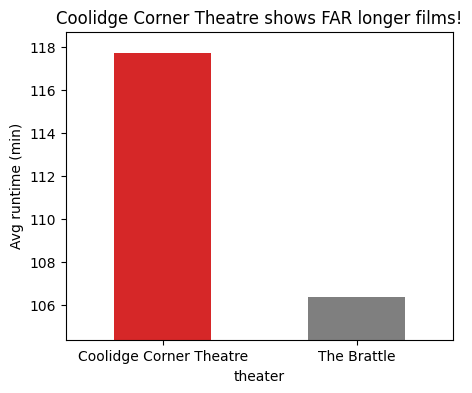

Means: {'Coolidge Corner Theatre': 117.7, 'The Brattle': 106.4}


In [38]:
# --- 5. PROVIDED CELL: do not edit. Critique the chart this draws. ----------
_rt = df.dropna(subset=["runtime"]).copy()
_rt["runtime_min"] = _rt["runtime"].dt.total_seconds() / 60
_top2 = _rt["theater"].value_counts().head(2).index
_means = _rt[_rt["theater"].isin(_top2)].groupby("theater")["runtime_min"].mean()

fig, ax = plt.subplots(figsize=(5, 4))
_means.plot(kind="bar", ax=ax, color=["C3", "C7"], rot=0)
ax.set_ylim(_means.min() - 2, _means.max() + 1)   # <- look closely
ax.set_ylabel("Avg runtime (min)")
ax.set_title(f"{_means.idxmax()} shows FAR longer films!")
plt.show()
print("Means:", _means.round(1).to_dict())

*The chart claims that Coolidge Corner Theatre shows much longer films than The Brattle, but the difference in mean runtime is only 11.3 minutes. The y-axis begins near 104 minutes, making the first bar appear much taller, while the title exaggerates the conclusion with “FAR.” I would redraw the bar chart with a zero baseline and label the exact means. I would also show the runtime distributions because the mean may be influenced by unusually long marathons.*

## Question 6: Resolve films to Wikipedia page IDs

<p>To enrich our data we need a <b>stable identifier</b> for each film's Wikipedia article. Query the <a href="https://www.mediawiki.org/wiki/API:Main_page">MediaWiki API</a> directly with <code>requests</code> — the numeric <code>pageid</code> is permanent even when article titles change. The <i>MediaWiki API</i> supplemental notebook walks through everything you need.</p>

<div class=prompt>

**Artifact:** a <code>wiki_id</code> column on <code>df</code> (the film's numeric pageid, or <code>NaN</code> when you can't resolve one confidently).

**Constraints:**
- Query each <b>unique film</b> once — not once per screening row.
- Cache your resolved IDs to disk (e.g. a CSV) so re-runs make <b>zero</b> lookup requests.
- Be polite: identify yourself with a User-Agent and handle rate-limiting (HTTP 429 / <code>maxlag</code>) gracefully. Sustained one-search-per-film traffic <i>will</i> get you throttled — plan your request budget.
- Report your coverage (share of screenings with a resolved ID) and show a few films you failed to match — what, if anything, do the misses have in common?

**AC209A (required; CS1090A optional):** parallelize whatever per-film requests remain with a small thread pool (max ~4 workers).
</div>

**Hint (request budget):** film articles follow strong title conventions — <i>"Title (YEAR film)"</i>, <i>"Title (film)"</i>, or just <i>"Title"</i>. The API's <code>action=query&titles=a|b|c</code> form checks up to <b>50 exact titles per request</b> (add <code>redirects=1</code>), which resolves most films in a handful of requests; full-text <code>search</code> is then only needed as a fallback for the stragglers. See the MediaWiki supplemental notebook.

In [41]:
# your code here
# Find the Wikipedia pageid of every unique film and cache the answers in a CSV.
WIKI_API = "https://en.wikipedia.org/w/api.php"
WIKI_CACHE = "data/wiki_ids.csv" # the cache: one row per film, re-runs read this instead of asking Wikipedia


def clean_title(title):
    """'Wicked VHS presents: Scream' -> 'Scream' (some theaters put the event name in front of the film title)."""
    return title.split(" presents: ")[-1].strip()


def get_candidates(title, year):
    """Article names a film could have on Wikipedia, best guess first (the hint's title conventions)."""
    names = []
    if pd.notna(year):
        names.append(f"{title} ({int(year)} film)")   # e.g. 'Psycho (1960 film)'
    names.append(f"{title} (film)")                   # e.g. 'Jaws (film)'
    names.append(title)                               # e.g. 'Rashomon'
    return names


def ask_wikipedia(params):
    """Send ONE request to the MediaWiki API. Returns the JSON answer, or None if it never worked."""
    params = {**params, "action": "query", "format": "json", "formatversion": 2, "maxlag": 5} # maxlag=5: "tell me if your servers are busy"
    for attempt in range(4):
        r = get_checked(WIKI_API, params=params)      # get_checked already waits and retries on HTTP 429 / 503
        if r is None:
            return None
        data = r.json()
        if data.get("error", {}).get("code") == "maxlag":   # Wikipedia can also say "busy" inside the JSON itself
            print("  Wikipedia is busy (maxlag) -- waiting 5s")
            time.sleep(5)
            continue
        return data
    return None


def look_up_titles(names):
    """Ask about up to 50 article names in ONE request. Returns {name we sent: page info} for the names that exist."""
    data = ask_wikipedia({"titles": "|".join(names), "redirects": 1,
                          "prop": "pageprops", "ppprop": "disambiguation|wikibase-shortdesc"})
    if data is None:
        return None
    query = data["query"]

    # Wikipedia may tidy a name we sent or follow a redirect. Record "what we sent, where it ended up".
    moved = {}
    for item in query.get("normalized", []) + query.get("redirects", []):
        moved[item["from"]] = item["to"]
    pages = {p["title"]: p for p in query["pages"] if not p.get("missing") and not p.get("invalid")}

    found = {}
    for name in names:
        final = name
        for _ in range(3):   # follow "tidied" and redirect steps (at most 3)
            final = moved.get(final, final)
        if final in pages:
            found[name] = pages[final]
    return found


def is_film(page, year):
    """Is this Wikipedia page confidently the film we want? (An article named 'Halloween' could be the holiday.)"""
    props = page.get("pageprops", {})
    if "disambiguation" in props:   # a list of possible meanings, not an article
        return False
    desc = props.get("wikibase-shortdesc", "").lower()    # Wikipedia's one-line summary, e.g. '1975 film by Steven Spielberg'
    if not page["title"].endswith("film)") and "film" not in desc:
        return False                                  # neither the title nor the summary says "film"
    years_in_desc = re.findall(r"\b(?:18|19|20)\d\d\b", desc)
    if years_in_desc and pd.notna(year) and abs(int(years_in_desc[0]) - int(year)) > 1:
        return False    # a film, but from a different year: probably a different film
    return True


def resolve_films(films, cache_file):
    """`films` has one row per unique film (film_key, title, year). Returns the cache: film_key, wiki_id, wiki_title."""
    if os.path.isfile(cache_file):
        cache = pd.read_csv(cache_file)
    else:
        cache = pd.DataFrame(columns=["film_key", "wiki_id", "wiki_title"])
    todo = films[~films["film_key"].isin(cache["film_key"])]          # only the films we have not looked up yet
    print(f"{len(films)} unique films | {len(cache)} already cached | {len(todo)} to look up")
    if len(todo) == 0:
        return cache   # everything cached: zero requests

    # 1. Every candidate article name for every film (a set drops duplicates; sorted keeps the batches the same each run)
    candidates = {row["film_key"]: get_candidates(clean_title(row["title"]), row["year"]) for _, row in todo.iterrows()}
    all_names = sorted({name for names in candidates.values() for name in names})

    # 2. Ask Wikipedia 50 names per request
    found, failed = {}, set()
    for i in range(0, len(all_names), 50):
        batch = all_names[i:i + 50]
        result = look_up_titles(batch)
        if result is None:
            failed.update(batch)          
        else:
            found.update(result)
        time.sleep(0.5)         
    print(f"{len(all_names)} candidate names checked in {-(-len(all_names) // 50)} requests")

    # 3. For each film, take the best candidate that exists AND looks like the right film
    new_rows = []
    for _, row in todo.iterrows():
        names = candidates[row["film_key"]]
        match = None
        for name in names:                 
            if name in found and is_film(found[name], row["year"]):
                match = found[name]
                break
        if match is None and any(name in failed for name in names):
            continue       # a request failed: do NOT cache a "miss"; try again next run
        new_rows.append({"film_key": row["film_key"],
                         "wiki_id": match["pageid"] if match else None,
                         "wiki_title": match["title"] if match else None})

    new_df = pd.DataFrame(new_rows)
    cache = new_df if len(cache) == 0 else pd.concat([cache, new_df], ignore_index=True)   # add the new answers to the old ones
    cache["wiki_id"] = cache["wiki_id"].astype("Int64")                # whole numbers (a float column would save 1001.0)
    cache.to_csv(cache_file, index=False)
    return cache


# Run: one row per unique film (same title but different year = different film)
year_text = df["year"].astype("string").fillna("unknown")   # a missing year becomes the word "unknown"
df["film_key"] = df["title"] + " | " + year_text
films = df[["film_key", "title", "year"]].drop_duplicates("film_key")
cache = resolve_films(films, WIKI_CACHE)

1299 unique films | 1299 already cached | 0 to look up


In [42]:
# your code here
# Add `wiki_id` to df, then report coverage and study the misses.
n_rows = len(df)
df["wiki_id"] = df["film_key"].map(cache.set_index("film_key")["wiki_id"]).astype("Int64")   # <NA> when unresolved
assert len(df) == n_rows   # verify the merge: no rows lost or duplicated

# Coverage: share of screenings and of unique films with a resolved id
print(f"screenings with a wiki_id: {df['wiki_id'].notna().mean():.1%}  ({df['wiki_id'].notna().sum()} of {len(df)})")
print(f"unique films with a wiki_id: {cache['wiki_id'].notna().mean():.1%}  ({cache['wiki_id'].notna().sum()} of {len(cache)})")

# Spot-check that the matches are right (the film title same as the Wikipedia article)
print("\nRandom matches:")
sample = cache.dropna(subset=["wiki_id"]).sample(8, random_state=0).merge(films, on="film_key")
display.display(sample[["title", "year", "wiki_title"]])

# Misses: which films failed, and what in common?
miss = df["wiki_id"].isna()
print("\nMost-screened films with NO wiki_id:")
print(df[miss]["title"].value_counts().head(12))

print("\nMiss rate by theater (busiest 8):")
print(miss.groupby(df["theater"]).agg(["mean", "size"]).sort_values("size", ascending=False).head(8).round(2))
print("\nMiss rate when the year is known:", round(miss[df["year"].notna()].mean(), 2),
      "| when the year is missing:", round(miss[df["year"].isna()].mean(), 2))

screenings with a wiki_id: 88.2%  (1501 of 1702)
unique films with a wiki_id: 86.7%  (1126 of 1299)

Random matches:


,title,year,wiki_title
0,Persona,1966,Persona (1966 film)
1,Lost Highway,1997,Lost Highway (film)
2,Galaxy Quest,1999,Galaxy Quest
3,The Dark Crystal,1982,The Dark Crystal
4,The Watermelon Woman,1997,The Watermelon Woman
5,The Fugitive,1993,The Fugitive (1993 film)
6,Smokey and the Bandit,1977,Smokey and the Bandit
7,Gunman's Walk,1958,Gunman's Walk



Most-screened films with NO wiki_id:
title
Nostalgia                                 5
Hundreds of Beavers                       4
The Lord of the Rings Trilogy             3
Murdering the Devil                       3
Youth in Fury                             2
Twin Peaks: The Return (Part 1 & 2)       2
Twin Peaks: The Return (Part 3 & 4)       2
School in the Crosshairs                  2
Don Hertzfeldt’s Animation Mixtape        2
Eyes of the Spider                        2
Twin Peaks: The Return (Part 11 & 12)     2
Double Feature: Chime + Serpent’s Path    2
Name: count, dtype: int64

Miss rate by theater (busiest 8):
                         mean  size
theater                            
The Brattle              0.09   656
Coolidge Corner Theatre  0.09   502
Harvard Film Archive     0.28   238
Somerville Theatre       0.06   145
West Newton Cinema       0.08    51
Museum of Fine Arts      0.09    33
Capitol Theatre          0.00    27
Cinema Salem             0.00     9

Miss r

*I resolved Wikipedia page IDs for 1,501 of 1,702 screenings (88.2%), representing 1,126 of 1,299 unique films (86.7%). The unresolved entries are often special programs, marathons, double features, or grouped television episodes rather than individual films. For example, The Lord of the Rings Trilogy, Twin Peaks: The Return (Part 1 & 2), and Double Feature: Chime + Serpent's Path; none of these is the title of a single Wikipedia article, so no candidate name can match. The Harvard Film Archive has the highest miss rate among the busiest theaters (28%), likely because its listings include more archival or unusually formatted programs. The remaining misses are mostly small, older, or niche single-film titles that either have no English Wikipedia article or have one under a name my three candidate patterns (Title (YEAR film), Title (film), Title) don't try.*

In [44]:
grader.check("q6")

q6 results: All test cases passed!

### 6a. Concurrency evidence — AC209A only (1 pt)

Question 6 required you to parallelise the per-film requests with a small thread pool. Point to where you did that, and show evidence it worked: either a timing comparison, or the batch and worker structure together with a measured runtime. One code or markdown cell is enough. Section 1's Appendix A11 covers the pattern, and the *MediaWiki API* supplemental shows the batched request this runs on top of.

*your answer here*

## Question 7: Cache Wikipedia page content to disk

<p>Acquire each resolved film's article content — <b>to disk, not into your DataFrame</b>. A DataFrame column of full pages bloats every downstream save to hundreds of megabytes; a directory of files keyed by <code>pageid</code> costs one lookup and makes the pipeline resumable.</p>

<p><b>Request budget, again — and harder.</b> Fetching ~1,300 rendered pages one-per-request (<code>action=parse</code>) triggers Wikipedia's throttling under sustained load. Instead, fetch each page's <b>wikitext source</b> via <code>action=query&amp;prop=revisions&amp;rvprop=content&amp;rvslots=main</code>, which accepts <b>50 <code>pageids</code> per request</b>; that's your whole cache in a couple dozen calls! The infobox data you'll need in Question 8 is present in the source (e.g. <code>| language = [[English language|English]]</code>).</p>

<div class=prompt>

**Artifact:** one file <code>data/wiki/&lt;pageid&gt;.txt</code> (wikitext) per resolved film.

**Constraints:**
- Guarded: request only pages not already cached, so a re-run when every page is already saved makes zero requests.
- Use the batched endpoint — one-request-per-page acquisition will lose credit.
- Report how many pages you cached and the total size on disk.

**AC209A (required; CS1090A optional):** issue the batch requests concurrently (2–3 workers over the chunk list).
</div>

In [48]:
# your code here
# Cache the wikitext of every resolved film's Wikipedia page as data/wiki/<pageid>.txt, 50 pages per request.
WIKI_DIR = "data/wiki"
os.makedirs(WIKI_DIR, exist_ok=True)


def get_wikitext_batch(pageids):
    """ONE request for up to 50 pages. Returns {pageid: wikitext} for the pages that came back with text."""
    data = ask_wikipedia({"pageids": "|".join(str(p) for p in pageids),
                          "prop": "revisions", "rvprop": "content", "rvslots": "main"})
    if data is None:
        return {}
    texts = {}
    for page in data["query"]["pages"]:
        if page.get("missing") or "revisions" not in page:   # page was deleted or the reply was cut off
            continue
        texts[page["pageid"]] = page["revisions"][0]["slots"]["main"]["content"]
    return texts


def cache_wikitext(wiki_ids, out_dir, batch_size=50):
    """Save the wikitext of every page not yet on disk. Returns the number of requests made."""
    n_requests = 0
    n_before = None
    while True:
        todo = [p for p in wiki_ids if not os.path.isfile(f"{out_dir}/{p}.txt")]   # skip pages already saved
        if not todo or len(todo) == n_before:
            break                         # nothing left to fetch
        n_before = len(todo)
        print(f"{len(todo)} pages still to fetch")
        for i in range(0, len(todo), batch_size):
            texts = get_wikitext_batch(todo[i:i + batch_size])
            n_requests += 1
            for pageid, text in texts.items():
                with open(f"{out_dir}/{pageid}.txt", "w", encoding="utf-8") as f:
                    f.write(text)
            time.sleep(0.5)   
    return n_requests


# One file per unique wiki_id (several screenings / film versions can share one page)
wiki_ids = sorted(int(p) for p in df["wiki_id"].dropna().unique())
n_requests = cache_wikitext(wiki_ids, WIKI_DIR)
print(f"{n_requests} requests made this run")

# Report how many pages are cached, how big are they, and are any missing
files = glob.glob(f"{WIKI_DIR}/*.txt")
total_mb = sum(os.path.getsize(f) for f in files) / 1_000_000
print(f"{len(files)} pages cached, {total_mb:.1f} MB on disk (needed {len(wiki_ids)})")
missing = [p for p in wiki_ids if not os.path.isfile(f"{WIKI_DIR}/{p}.txt")]
print("pages we could not cache:", missing if missing else "none")

0 requests made this run
1125 pages cached, 45.6 MB on disk (needed 1125)
pages we could not cache: none


In [49]:
grader.check("q7")

q7 results: All test cases passed!

### 7a. Concurrency evidence — AC209A only (1 pt)

Question 7 required you to issue the batch requests concurrently. Point to where you did that, and show evidence it worked: either a timing comparison, or the batch and worker structure together with a measured runtime. One code or markdown cell is enough. Section 1's Appendix A11 covers the pattern.

*your answer here*

## Question 8: Enrich the data and ask a new question

### 8.1 Extract new data

Extract at least one new piece of data per film from your cached Wikipedia pages (the infobox is the most standardized place to start: language, country, box office, starring cast, ...). Add it to `df` as new column(s) — **verify the merge** — display the result, and briefly describe your extraction strategy and the messiness you had to handle. Cache the derived table (e.g. a small CSV keyed by `wiki_id`) so re-runs skip the extraction.

### 8.2 Ask one new question

Using your Wikipedia-derived column(s): state the question and why it's interesting, your approach, at least one well-labeled plot, and your interpretation.

### 8.3 Save the enriched table

Save it (without any page content!) as `data/movies_enriched.csv`.

In [53]:
# your code here
def get_infobox(text):
    """Return the '{{Infobox film ... }}' block of a page ('' if it has none). The block contains other {{templates}}, so count the braces."""
    start = re.search(r"\{\{\s*infobox film", text, re.IGNORECASE)
    if start is None:
        return ""
    depth = 0
    for m in re.finditer(r"\{\{|\}\}", text[start.start():]):
        depth += 1 if m.group() == "{{" else -1              # every {{ opens a template, every }} closes one
        if depth == 0:                                        # the brace that opened the infobox is now closed
            return text[start.start(): start.start() + m.end()]
    return text[start.start():]                               # unbalanced braces: take the rest of the page


def get_fields(box):
    """{'language': raw text, 'country': raw text, ...}: one entry per '| name = value' line of the infobox."""
    fields = {}
    pattern = r"^\s*\|\s*([\w ]+?)\s*=\s*(.*?)(?=^\s*\|\s*[\w ]+?\s*=|\Z)" # a value runs until the next '| name =' line
    for name, value in re.findall(pattern, box, flags=re.MULTILINE | re.DOTALL):
        fields[name.lower().replace(" ", "_")] = value
    return fields


def strip_markup(value):
    """Remove the wiki markup that is not part of the data: comments, footnotes, links, bold/italics, html."""
    value = re.sub(r"<!--.*?-->", "", value, flags=re.DOTALL)                        # <!-- editor comments -->
    value = re.sub(r"<ref[^>]*?/>|<ref[^>]*?>.*?</ref>", "", value, flags=re.DOTALL)  # <ref>footnotes</ref>
    value = re.sub(r"\[\[(?:[^\]|]*\|)?([^\]]*)\]\]", r"\1", value)                 # [[English language|English]] -> English
    value = re.sub(r"'{2,}", "", value)                                              # ''italics'' and '''bold'''
    value = value.replace("&nbsp;", " ")
    return value


def first_item(value):
    """A field may hold a list ({{plainlist|* A * B}}, A<br>B, {{ubl|A|B}}). Return only the first item."""
    value = strip_markup(value)
    value = re.sub(r"<br\s*/?>|\{\{[^|{}]*\||\}\}|\||\*", "\n", value, flags=re.IGNORECASE)   # every list separator -> a new line
    value = re.sub(r"<[^>]+>", "", value)    # any leftover html tags
    items = [line.strip() for line in value.split("\n") if line.strip()]
    return items[0] if items else None


def parse_gross(value):
    """'$1.2 million' / 'US$ 8,500,000' / '$2.1 billion' -> millions of US dollars. None if empty or not in dollars."""
    text = strip_markup(value)
    text = re.sub(r"\{\{\s*US\$\s*\|", "$", text, flags=re.IGNORECASE).replace("US$", "$")   # {{US$|1.2 million}} and US$ -> $
    m = re.search(r"(?<![A-Za-z])\$\s*([\d,]+(?:\.\d+)?)\s*(million|billion|m\b|bn\b)?", text, re.IGNORECASE)   # (A$ or C$ are not US dollars)
    if m is None:
        return None                                                                  # empty, or another currency (£, €, ₹ ...)
    number = float(m.group(1).replace(",", ""))
    unit = (m.group(2) or "").lower()
    if unit in ("million", "m"):
        return number
    if unit in ("billion", "bn"):
        return number * 1000
    return number / 1_000_000 if number >= 10_000 else None                          # '$5,000,000' is fine; '$1.2-3 million' (a range) is skipped


COUNTRY_NAMES = {"US": "United States", "USA": "United States", "U.S.": "United States", "America": "United States",
                 "UK": "United Kingdom", "England": "United Kingdom"}                # the same country is written several ways


def read_page(path):
    """One row of data from one cached page file."""
    with open(path, encoding="utf-8") as f:
        fields = get_fields(get_infobox(f.read()))
    country = first_item(fields.get("country", fields.get("countries", "")))
    return {"wiki_id": int(os.path.basename(path)[:-4]),                             # '12345.txt' -> 12345
            "language": first_item(fields.get("language", fields.get("languages", ""))),
            "country": COUNTRY_NAMES.get(country, country),
            "gross_musd": parse_gross(fields.get("gross", fields.get("box_office", "")))}


def build_infobox_table(page_glob, csv_file):
    """Extract the infobox data of every page once and save it (keyed by wiki_id). A re-run just reads the CSV."""
    if os.path.isfile(csv_file):
        return pd.read_csv(csv_file)
    info = pd.DataFrame([read_page(path) for path in sorted(glob.glob(page_glob))])
    info.to_csv(csv_file, index=False)
    return info


info = build_infobox_table("data/wiki/*.txt", "data/wiki_infobox.csv")
print("share of pages with each field:")
print(info[["language", "country", "gross_musd"]].notna().mean().round(2))

# Add the new columns to df. (Drop them first so re-running this cell does not create language_x / language_y.)
new_columns = ["language", "country", "gross_musd"]
n_rows = len(df)
df = df.drop(columns=[c for c in new_columns if c in df.columns])
df = df.merge(info, on="wiki_id", how="left", validate="m:1")        # left: keep every screening; m:1: each wiki_id appears once in `info`
assert len(df) == n_rows, "the merge changed the number of rows!"

# Verify the merge: films with a wiki_id should now have data, films without one should not
print("\nscreenings with a country:", df["country"].notna().sum(), "| with a wiki_id:", df["wiki_id"].notna().sum())
display.display(df[df["wiki_id"].notna()][["title", "year", "wiki_id"] + new_columns].sample(8, random_state=0))

share of pages with each field:
language      0.98
country       0.99
gross_musd    0.67
dtype: float64

screenings with a country: 1485 | with a wiki_id: 1501


,title,year,wiki_id,language,country,gross_musd
532,A Woman Is a Woman,1961,1644858,French,France,0.209837
11,Thomasine & Bushrod,1974,4340576,English,United States,NaN
1701,Au Revoir les Enfants,1987,1688060,French,France,4.500000
63,Us,2019,57371131,English,United States,256.100000
912,Cooley High,1975,1692374,English,United States,13.000000
1324,Bottle Rocket,1996,524139,English,United States,0.560069
1299,Move Ya Body: The Birth of House,2025,78877930,English,United States,NaN
194,El Topo,1970,1844221,Spanish,Mexico,NaN


*I first located the film infobox in each cached Wikipedia page and extracted the language, country, and box-office fields. I then removed wiki markup, citations, links, and HTML tags; kept the first value when multiple languages or countries were listed; standardized country names such as “US,” “USA,” and “U.S.”; and converted dollar-denominated grosses to millions of U.S. dollars. The main messiness came from nested templates, inconsistent field names and country labels, lists of multiple values, missing fields, different currencies, and ambiguous box-office ranges. Values that could not be interpreted confidently were recorded as NaN. I saved one cleaned record per wiki_id in a CSV and merged it into df using a many-to-one left join. I verified that the merge preserved all screening rows. Among the matched Wikipedia pages, 98% have language data, 99% have country data, and 67% have usable box-office data.*

1485 of 1702 screenings (87%) have a country


country,United States,United Kingdom,Japan,France,Other
theater,,,,,
The Brattle,61.9,10.2,5.9,4.7,17.3
Coolidge Corner Theatre,71.3,7.0,5.0,3.1,13.6
Harvard Film Archive,26.2,13.1,18.5,7.7,34.5
Somerville Theatre,80.3,9.1,4.5,0.8,5.3
West Newton Cinema,82.6,2.2,2.2,2.2,10.9
Museum of Fine Arts,37.9,3.4,13.8,6.9,37.9


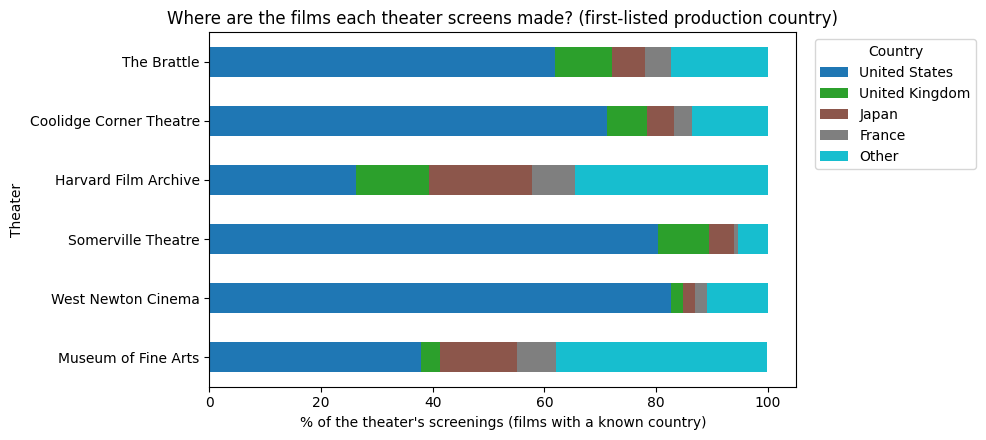

In [55]:
# your code here
# Question: which theaters show the most internationally diverse films? 
known = df.dropna(subset=["country"])                                 
print(f"{len(known)} of {len(df)} screenings ({len(known) / len(df):.0%}) have a country")

top6 = df["theater"].value_counts().head(6).index    # the 6 busiest theaters
top_countries = known["country"].value_counts().head(4).index         # the 4 most common countries overall
group = known["country"].where(known["country"].isin(top_countries), "Other")

# Percentage of each theater's screenings by country group
share = pd.crosstab(known["theater"], group, normalize="index") * 100
share = share.loc[top6, list(top_countries) + ["Other"]].round(1)
display.display(share)

ax = share.plot(kind="barh", stacked=True, figsize=(10, 4.5), colormap="tab10")
ax.invert_yaxis()
ax.set_xlabel("% of the theater's screenings (films with a known country)")
ax.set_ylabel("Theater")
ax.set_title("Where are the films each theater screens made? (first-listed production country)")
ax.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

*Question: Which of the six busiest theaters screen the most internationally diverse selection of films? This is interesting because it shows how theaters differ in their emphasis on U.S. versus international cinema.*

*Approach: I grouped films by their first-listed production country on Wikipedia. I kept the four most common countries and combined the rest as “Other.” I then calculated each country group’s share of screenings at each theater and compared them using a 100% stacked bar chart. Country data are available for 1,485 of 1,702 screenings (87%).*

*Interpretation: The Harvard Film Archive and Museum of Fine Arts screen the largest shares of international films. U.S. films account for 26.2% of screenings at the Harvard Film Archive and 37.9% at the Museum of Fine Arts, compared with more than 80% at Somerville Theatre and West Newton Cinema. The results include only films with known country data and classify co-productions by their first-listed country.*

In [57]:
# your code here
# Save the enriched table (screenings + wiki_id + language/country/gross)
df.to_csv("data/movies_enriched.csv", index=False)

# Check the shape and check that no cell holds a whole page
check = pd.read_csv("data/movies_enriched.csv")
print("saved:", check.shape, "| size:", round(os.path.getsize("data/movies_enriched.csv") / 1000), "KB")
print("columns:", list(check.columns))
longest = check.select_dtypes(exclude="number").astype(str).apply(lambda col: col.str.len().max()).max()
print("longest text value:", longest, "characters (a wiki page would be thousands)")
assert longest < 500, "some column contains page content!"

saved: (1702, 13) | size: 260 KB
columns: ['title', 'directors', 'year', 'genre', 'runtime', 'theater', 'screen_date', 'screen_times', 'film_key', 'wiki_id', 'language', 'country', 'gross_musd']
longest text value: 101 characters (a wiki page would be thousands)


In [58]:
grader.check("q8")

q8 results: All test cases passed!

### 8a. SQL — AC209A only (3 pts)

The DataFrame operations you've used all assignment — subset, aggregate, join, transform — are the same four verbs SQL speaks, and SQL is the dialect most of industry says them in (see the *DuckDB: SQL on files* supplemental). Pose one Q5-style analytical question about your enriched screening data and answer it with a **single SQL query** run via `duckdb` directly against `data/movies_enriched.csv`. Display the result and interpret it in 2–3 sentences. Prefer a question where SQL earns its keep (a grouped ranking, a window function, a multi-way aggregation).

In [60]:
# your code here
...

*your answer here*

## Question 9: The decision — program Halloween weekend

<p>You now advise a consortium of the <b>four theaters with the most screenings</b> in your data. They want a coordinated plan for <b>Halloween weekend 2026 (Fri Oct 30 – Sun Nov 1)</b>: each theater programs a small slate, with the goal of maximizing <b>total ticket revenue across the consortium</b> — so the theaters should draw large audiences <i>without competing head-to-head for the same one</i>.</p>

Produce a recommendation, supported by your data. There is no single right answer; you are graded on the clarity of your reasoning and on whether the data you present actually supports the recommendation you make.

### 9.1 Theater personalities

**Identify the four theaters** and characterize their programming "personalities" (the audience each one's history suggests it draws): genre mix, film vintage, language profile — whatever you judge informative. **Profile at least two theaters in depth** (all four encouraged), with at least one supporting visualization.

,screenings,unique films,median release year,% before 1980,% non-US,% non-English,% horror,% Fri-Sun,% late-night
theater,,,,,,,,,
The Brattle,656,480,1986.0,36.0,38.0,22.0,14.0,52.0,3.0
Coolidge Corner Theatre,502,461,1992.0,28.0,29.0,18.0,15.0,50.0,30.0
Harvard Film Archive,238,207,1966.0,71.0,74.0,59.0,0.0,81.0,0.0
Somerville Theatre,145,131,1983.0,39.0,20.0,11.0,18.0,48.0,13.0


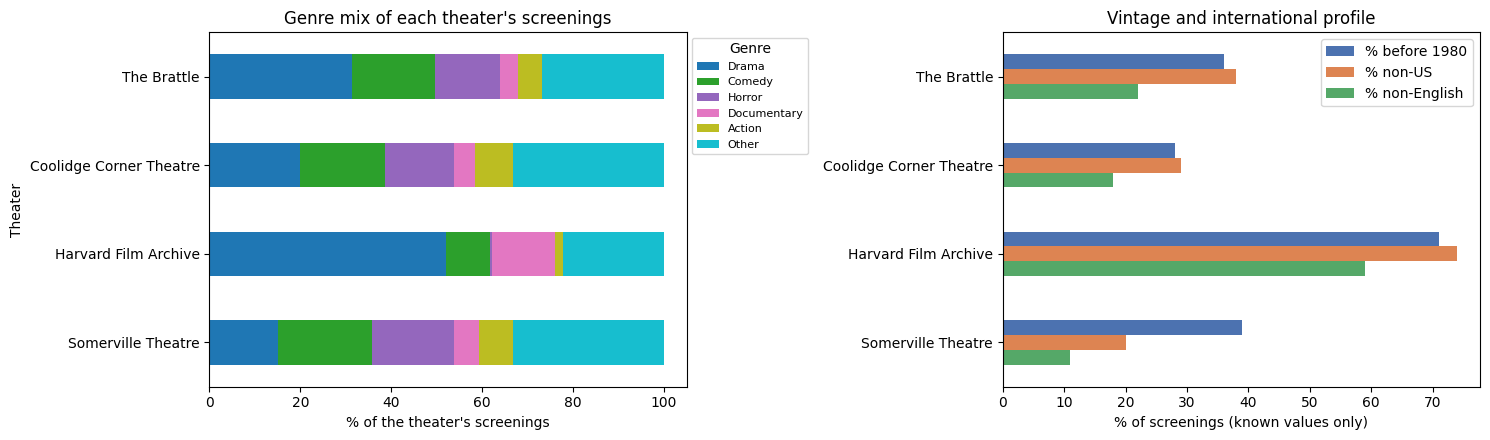

In [64]:
# your code here
# 9.1 Theater personalities: the 4 busiest theaters and what each one is "like"
top4 = df["theater"].value_counts().head(4).index               # the 4 theaters with the most screenings
t4 = df[df["theater"].isin(top4)].copy()                        # keep only their screenings
for col in t4.select_dtypes("category").columns:                # if any column is a 'category' dtype, make it a plain column
    t4[col] = t4[col].astype(object)        

# --- Yes/no columns (1.0 = yes, 0.0 = no, NaN = we don't know), so that a group's average = a share ---
year = t4["year"].astype(float)
t4["pre1980"] = (year < 1980).astype(float).where(year.notna())                                       # film released before 1980?
t4["non_us"] = (t4["country"] != "United States").astype(float).where(t4["country"].notna())          # made outside the US?
t4["non_english"] = (t4["language"] != "English").astype(float).where(t4["language"].notna())         # not in English?
t4["fri_sun"] = (t4["screen_date"].dt.dayofweek >= 4).astype(float)                                   # Fri, Sat or Sun (Mon=0 ... Sun=6)
t4["late_night"] = t4["screen_times"].str.contains(r"\b(?:10|11):\d\d PM", regex=True).astype(float)  # a show at 10 or 11 PM
t4["horror"] = (t4["genre"] == "Horror").astype(float)

g = t4.groupby("theater")                                        # one group per theater
profile = pd.DataFrame({
    "screenings": g.size(),
    "unique films": g["film_key"].nunique(),
    "median release year": g["year"].median(),
    "% before 1980": g["pre1980"].mean() * 100,
    "% non-US": g["non_us"].mean() * 100,
    "% non-English": g["non_english"].mean() * 100,
    "% horror": g["horror"].mean() * 100,
    "% Fri-Sun": g["fri_sun"].mean() * 100,
    "% late-night": g["late_night"].mean() * 100,
}).loc[top4].round(0)
display.display(profile)

# --- Figure: genre mix (left) and vintage / international profile (right) ---
main_genres = ["Drama", "Comedy", "Horror", "Documentary", "Action"]
genre_group = t4["genre"].where(t4["genre"].isin(main_genres), "Other")          # everything else -> "Other"
mix = pd.crosstab(t4["theater"], genre_group, normalize="index") * 100           # each theater's genre shares add up to 100
mix = mix.loc[top4, main_genres + ["Other"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))
mix.plot(kind="barh", stacked=True, ax=ax1, colormap="tab10")
ax1.invert_yaxis()                                                                # busiest theater on top
ax1.set_title("Genre mix of each theater's screenings")
ax1.set_xlabel("% of the theater's screenings")
ax1.set_ylabel("Theater")
ax1.legend(title="Genre", bbox_to_anchor=(1.0, 1), loc="upper left", fontsize=8)

profile[["% before 1980", "% non-US", "% non-English"]].plot(kind="barh", ax=ax2, color=["#4C72B0", "#DD8452", "#55A868"])
ax2.invert_yaxis()
ax2.set_title("Vintage and international profile")
ax2.set_xlabel("% of screenings (known values only)")
ax2.set_ylabel("")
plt.tight_layout()
plt.show()

*The four busiest theaters are The Brattle, Coolidge Corner Theatre, Harvard Film Archive, and Somerville Theatre.*

*The Brattle has the most screenings and a broad genre mix. Its median release year is 1986; 36% of its films were released before 1980, 38% are non-U.S., and 22% are non-English. Its programming suggests an audience interested in repertory films, international cinema, and a variety of genres.*

*Coolidge Corner Theatre screens somewhat newer films, with a median release year of 1992. It has the highest late-night share at 30%, while 15% of its screenings are horror. This suggests a strong audience for late-night genre programming as well as mainstream and repertory films.*

*Harvard Film Archive has the clearest archival and international focus. Its median release year is 1966; 71% of its films are from before 1980, 74% are non-U.S., and 59% are non-English. Its screenings are concentrated from Friday through Sunday, but the dataset contains almost no horror or late-night programming.* 

*Somerville Theatre has the highest horror share at 18% and a median release year of 1983. Its programming is mostly U.S. and English-language films, with some late-night screenings. This suggests an audience for accessible genre films, especially horror and comedy.*

*Overall, the theaters have distinct profiles: Harvard Film Archive is the most archival and international, Coolidge has the strongest late-night identity, Somerville has the strongest horror concentration, and The Brattle offers the broadest repertory mix.*

### 9.2 Your draw proxy

You have no revenue data, so state explicitly what you will use as a stand-in for "how many people a film/genre draws at this theater" and defend it in a sentence or two.

In [67]:
# your code here
# 9.2 Draw proxy: how long does a theater KEEP a film on its calendar, and does it bring the film back?
# Idea: a theater gives more dates to (and re-books) the films that fill its seats. We have no ticket sales, so this "revealed demand" is our stand-in.
t4 = t4.sort_values("screen_date")                                               # (t4 comes from the 9.1 cell)
t4["days_since_prev"] = t4.groupby(["theater", "film_key"])["screen_date"].diff().dt.days   # gap to the previous screening of the SAME film at the SAME theater

runs = t4.groupby(["theater", "film_key"]).agg(
    title=("title", "first"),
    genre=("genre", "first"),
    run_days=("screen_date", "nunique"),                                         # on how many different dates was it shown?
    longest_gap=("days_since_prev", "max"),                                      # biggest gap between two of its screenings
).reset_index()
runs["comes_back"] = runs["longest_gap"] > 45                                    # shown again 45+ days later = brought back

# Why not "number of showtimes per day"? Because it is almost always 1, so it can't tell films apart:
t4["n_showtimes"] = t4["screen_times"].str.count(",") + 1                        # '4:00 PM, 9:00 PM' has 1 comma -> 2 showtimes
print("average showtimes per listing:")
print(t4.groupby("theater")["n_showtimes"].mean().loc[top4].round(2))

# The proxy, per theater: average number of dates per film, share of films with a run of 2+ dates, and number of films brought back
summary = runs.groupby("theater").agg(
    avg_dates_per_film=("run_days", "mean"),
    pct_multi_date=("run_days", lambda s: (s >= 2).mean() * 100),
    films_brought_back=("comes_back", "sum"),
).loc[top4].round(2)
print("\nDraw proxy by theater:")
display.display(summary)

# The same proxy for HORROR only (what matters for Halloween)
horror = runs[runs["genre"] == "Horror"]
print("\nHorror films only:")
display.display(horror.groupby("theater").agg(horror_films=("title", "size"), avg_dates=("run_days", "mean"),
                                              brought_back=("comes_back", "sum")).reindex(top4).round(2))

# Which horror / cult titles does each theater keep or bring back? (the safest crowd-pleasers)
keepers = runs[(runs["comes_back"] | (runs["run_days"] >= 3)) & runs["genre"].isin(["Horror", "Comedy", "Fantasy", "SciFi"])]
display.display(keepers.sort_values(["theater", "run_days"], ascending=[True, False])[["theater", "title", "genre", "run_days", "comes_back"]])

average showtimes per listing:
theater
The Brattle                1.29
Coolidge Corner Theatre    1.01
Harvard Film Archive       1.00
Somerville Theatre         1.07
Name: n_showtimes, dtype: float64

Draw proxy by theater:


,avg_dates_per_film,pct_multi_date,films_brought_back
theater,,,
The Brattle,1.36,23.75,22
Coolidge Corner Theatre,1.09,5.86,14
Harvard Film Archive,1.15,13.53,1
Somerville Theatre,1.11,8.40,6



Horror films only:


,horror_films,avg_dates,brought_back
theater,,,
The Brattle,64,1.45,4
Coolidge Corner Theatre,68,1.12,2
Harvard Film Archive,1,1.00,0
Somerville Theatre,25,1.04,0


,theater,title,genre,run_days,comes_back
122,Coolidge Corner Theatre,Eraserhead,Horror,5,True
373,Coolidge Corner Theatre,The Lord of the Rings Trilogy,Fantasy,3,True
393,Coolidge Corner Theatre,The Rocky Horror Picture Show,Comedy,3,True
17,Coolidge Corner Theatre,A Clockwork Orange,SciFi,2,True
171,Coolidge Corner Theatre,Hundreds of Beavers,Comedy,2,True
189,Coolidge Corner Theatre,It Follows,Horror,2,True
443,Coolidge Corner Theatre,When Harry Met Sally...,Comedy,2,True
679,Somerville Theatre,Batman,Fantasy,3,False
784,Somerville Theatre,The Rocky Horror Picture Show,Comedy,3,True
725,Somerville Theatre,Hundreds of Beavers,Comedy,2,True


*I use the number of screening dates per film and whether a film returns after at least 45 days as proxies for audience draw. Theaters are more likely to extend or rebook films that attract viewers, while showtimes per listing provide little information because almost every listing has only one showtime. This is an indirect measure of demand, since actual attendance and revenue are unavailable.*

### 9.3 The slates

Recommend **2–3 films (or film types)** for each theater you profiled, and at least a one-line programming direction for the others. Justify choices with your profiles and draw proxy, and explain how the slates avoid cannibalizing each other.

*The Brattle: The Shining, Alien, and Young Frankenstein. All three were previously screened and later brought back, supporting repeat demand.*

*Coolidge Corner Theatre: Eraserhead, It Follows, and The Rocky Horror Picture Show. All three were previously brought back, and Coolidge has the strongest late-night profile.*

*Harvard Film Archive: A non-horror program of older international and non-English films from its own screening history. This matches its archival profile (71% pre-1980, 74% non-U.S., and 59% non-English), and provides alternative for viewers not seeking horror.*

*Somerville Theatre: Halloween, Friday the 13th, and Beetlejuice. All appeared in Somerville’s past programming, and its 18% horror share supports a mainstream Halloween slate.*

*The slates avoid direct competition by separating repertory horror at The Brattle, cult late-night horror at Coolidge, archival international counterprogramming at Harvard Film Archive, and mainstream Halloween films at Somerville.*

### 9.4 Uncertainties

At least two ways this analysis could mislead the consortium, and what data you'd want next.

*No ticket data, so audience draw is inferred. Because the theaters have different capacities and ticket prices, more screening dates do not necessarily mean more revenue. I would want ticket sales, seats sold, capacity, and ticket prices for each showing during previous Halloween weekends.* 

*The data are incomplete and time-limited. Some months are missing, and each snapshot covers only about two weeks. The dataset includes only two previous Halloween periods and ends on October 15, 2026, before theaters may have published their full Halloween schedules. Halloween also falls on different weekdays each year. I would want complete historical schedules and the currently announced 2026 schedules.*

*The Wikipedia enrichment is incomplete. Of 1,702 screenings, 201 have no wiki_id, and more are missing country, language, or box-office information. Missing records often involve special events, double features, and lesser-known films. International co-productions are also classified only by their first-listed country. These issues may bias the theater profiles.*

## Question 10: Reproducibility reflection, AI disclosure & data submission

### 10.1 Reproducibility reflection

A short paragraph or bullets: walk through your pipeline and identify what is **reproducible** (same result on every re-run, for anyone) and what is **brittle or non-reproducible** — and how you mitigated each risk. Consider at least: the live fetch (Q1), your HTML parsing (Q2), the Wayback snapshots (Q3), and the Wikipedia lookups & content (Q6–Q8). Also: the raw wiki cache is *deliberately excluded* from your submission (see 10.3) — what does that exclusion mean for the reproducibility of your Q8 columns?

*Live fetch (Q1): The downloaded HTML is cached, so rerunning the notebook parses the same file. Without the cache, the result could change because the live website changes. Submitting the cached HTML makes this step reproducible.*

*HTML parsing (Q2): The parser produces the same result from the same HTML, but it depends on the site’s CSS structure. A site redesign could break it. I kept the original HTML and used a separate parser for an older layout found in Q3.*

*Wayback snapshots (Q3): The snapshot list and downloaded pages are cached, so reruns use the same files. Without these caches, Archive.org could return different snapshots or fail because of rate limits. The saved manifest, HTML files, and retry logic reduce these risks.*

*Wikipedia data (Q6–Q8): Wikipedia content can change. I cached the resolved IDs, page text, and extracted infobox fields so reruns do not repeat the lookups and return the same results.*

*Excluded raw Wikipedia cache: The submitted wiki_ids.csv and wiki_infobox.csv reproduce the final Q8 columns without accessing Wikipedia. However, because the raw wikitext is excluded, a grader cannot rerun or independently verify the extraction against the exact Wikipedia content originally used.*

### 10.2 AI disclosure

A few sentences: how you used AI tools on this assignment (which parts, what for) and — the part we grade — **what you did to verify their output** before signing off on it. There is no penalty for extensive AI use; there is a penalty for unverified submission.

*I used AI to help debug Q8.3, the Wikipedia infobox parser, especially the regular expressions for nested templates and inconsistent field formats. It also helped me handle edge cases such as multiple countries, wiki markup, missing values, and different box-office formats. I manually compared a sample of extracted values with the original Wikipedia pages, including records with nested templates, multiple countries, missing fields, and unusual box-office formats. I also checked missing-value rates, confirmed that each wiki_id appears only once in the extracted table, and verified that the merge preserves the original number of screening rows without creating duplicates.*

### 10.3 Data submission

Run the provided manifest cell below. You will upload these files with your notebook so it can be re-run and graded *without any network access*. The full set must stay **under 25 MB** — this is why Q7 cached page content to disk instead of stuffing it in the DataFrame.

In [78]:
# --- PROVIDED CELL: submission manifest. Run before submitting; do not edit.
# Your submission = this notebook + every file listed below (data/wiki/ raw
# page cache is deliberately excluded). The set must total <= 25 MB.
SUBMISSION_FILES = sorted(
    glob.glob("data/html/*.html")     # live page + pinned snapshots
    + glob.glob("data/*.json")        # movies.json, wayback manifest, ...
    + glob.glob("data/*.csv")         # your derived caches / enriched table
)

assert SUBMISSION_FILES, "No data files found -- did the pipeline run?"
assert any("movies_enriched" in f for f in SUBMISSION_FILES), \
    "data/movies_enriched.csv is required (Q8)."

total_mb = sum(os.path.getsize(f) for f in SUBMISSION_FILES) / 1e6
for f in SUBMISSION_FILES:
    print(f"{os.path.getsize(f)/1e6:8.2f} MB  {f}")
print(f"{'-'*40}\n{total_mb:8.2f} MB  total ({len(SUBMISSION_FILES)} files)")

assert total_mb <= 25, "Submission exceeds the 25 MB budget!"
print("\nWithin the 25 MB budget -- ready to submit.")

    0.28 MB  data/html/screenboston.html
    0.01 MB  data/html/snapshot_20240328.html
    0.29 MB  data/html/snapshot_20240524.html
    0.33 MB  data/html/snapshot_20241006.html
    0.24 MB  data/html/snapshot_20241101.html
    0.17 MB  data/html/snapshot_20241206.html
    0.18 MB  data/html/snapshot_20250326.html
    0.22 MB  data/html/snapshot_20250428.html
    0.20 MB  data/html/snapshot_20250616.html
    0.18 MB  data/html/snapshot_20250622.html
    0.33 MB  data/html/snapshot_20250903.html
    0.25 MB  data/html/snapshot_20251021.html
    0.26 MB  data/html/snapshot_20251127.html
    0.13 MB  data/html/snapshot_20251215.html
    0.26 MB  data/html/snapshot_20260123.html
    0.20 MB  data/html/snapshot_20260312.html
    0.16 MB  data/html/snapshot_20260413.html
    0.21 MB  data/html/snapshot_20260513.html
    0.23 MB  data/html/snapshot_20260616.html
    0.19 MB  data/html/snapshot_20260708.html
    0.21 MB  data/html/snapshot_20260721.html
    0.25 MB  data/html/snapshot_2026082

In [79]:
grader.check("q10_3")

q10_3 results: All test cases passed!

## Wrap-up

<div class="alert alert-info" style="color: #4a4a4a; background-color: #fbe8ff; border-color: #eed4db; border-width: 1px; border-radius: 3px; padding: 10px;">

* Which aspect(s) of the assignment did you find most challenging — conceptually or in implementation? Any remaining questions?

* How many hours did you spend on this assignment? Store an int or float in `hours_spent_on_hw` (if you worked in a group, report the average per person).

</div>

*Q8.3 is challenging.*

In [82]:
hours_spent_on_hw = 12

In [83]:
grader.check("wrapup")

wrapup results: All test cases passed!

In [84]:
notebook_end = time.time()
print(f"It took {(notebook_end - notebook_start)/60:.2f} minutes for this notebook to run")

It took 0.03 minutes for this notebook to run


🌈 **This concludes HW1. Thank you!**